# 📊 NSE Institutional Flow & Sentiment Engine
**Automated Daily ETL Pipeline & Market Impact Dashboard**

This notebook ingests raw daily FII/DII cash market data, cleanses the formatting, merges it with historical Nifty 50 closing prices, and generates actionable market intelligence including streak tracking and net sentiment analysis.

In [1]:
import pandas as pd

# The final, clean load of your February data
# We use forward slashes (/) to keep Python happy on Windows
df = pd.read_csv('../data/fii_history_2026-02.csv')

# Look at the first 5 rows to make sure the columns are correct
print("✅ Project Database: Connected")
df.head()

✅ Project Database: Connected


,FII Rs Crores,Unnamed: 1,Unnamed: 2,DII Rs Crores,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Date,Gross Purchase,Gross Sales,Net Purchase / Sales,Gross Purchase,Gross Sales,Net Purchase / Sales
1,Total,339315.95,345956.73,-6640.78,346722.22,308299.11,38423.11
2,27-Feb-2026,"36,699.66","44,236.02","-7,536.36","24,867.72","12,574.91","12,292.81"
3,26-Feb-2026,"14,607.90","18,073.89","-3,465.99","19,242.72","14,211.15","5,031.57"
4,25-Feb-2026,"30,369.48","27,377.84","2,991.64","18,346.49","13,227.92","5,118.57"


In [2]:
# 1. Skip the junk headers and rename
df_clean = df.iloc[2:].copy()
df_clean.columns = ['Date', 'FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']

# 2. Reset the index
df_clean = df_clean.reset_index(drop=True)

# 3. THE FIX: Remove commas and whitespace before converting to numbers
cols_to_fix = ['FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']

for col in cols_to_fix:
    # This line removes commas and extra spaces
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '').str.strip()
    # Now we convert to actual numbers
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("✅ Stage 2: Data Cleaning Complete (Commas Removed)")
df_clean.head()

✅ Stage 2: Data Cleaning Complete (Commas Removed)


,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net
0,27-Feb-2026,36699.66,44236.02,-7536.36,24867.72,12574.91,12292.81
1,26-Feb-2026,14607.90,18073.89,-3465.99,19242.72,14211.15,5031.57
2,25-Feb-2026,30369.48,27377.84,2991.64,18346.49,13227.92,5118.57
3,24-Feb-2026,20550.91,20653.44,-102.53,18580.96,15419.74,3161.22
4,23-Feb-2026,15294.02,11810.32,3483.70,12360.86,13653.10,-1292.24


In [3]:
# Calculate Total Net Flows
fii_net_total = df_clean['FII_Net'].sum()
dii_net_total = df_clean['DII_Net'].sum()

print(f"📊 FEBRUARY 2026 MARKET SUMMARY")
print(f"-------------------------------")
print(f"FII Net Movement: {fii_net_total:,.2f} Cr")
print(f"DII Net Movement: {dii_net_total:,.2f} Cr")

# Logic to determine who is driving the market
if fii_net_total < 0 and dii_net_total > 0:
    print("\n⚠️ TREND: FIIs are exiting, but DIIs are absorbing the pressure.")
elif fii_net_total > 0:
    print("\n🚀 TREND: FIIs are bullish. Global money is flowing in!")

📊 FEBRUARY 2026 MARKET SUMMARY
-------------------------------
FII Net Movement: -6,640.78 Cr
DII Net Movement: 38,423.11 Cr

⚠️ TREND: FIIs are exiting, but DIIs are absorbing the pressure.


In [4]:
# 1. Find the 3 biggest selling days by FIIs
top_selling = df_clean.sort_values(by='FII_Net', ascending=True).head(3)

# 2. Find the 3 biggest buying days by FIIs
top_buying = df_clean.sort_values(by='FII_Net', ascending=False).head(3)

print("🚨 TOP 3 PANIC DAYS (Highest FII Selling):")
print(top_selling[['Date', 'FII_Net']])

print("\n💎 TOP 3 ACCUMULATION DAYS (Highest FII Buying):")
print(top_buying[['Date', 'FII_Net']])

🚨 TOP 3 PANIC DAYS (Highest FII Selling):
           Date  FII_Net
0   27-Feb-2026 -7536.36
10  13-Feb-2026 -7395.41
1   26-Feb-2026 -3465.99

💎 TOP 3 ACCUMULATION DAYS (Highest FII Buying):
           Date  FII_Net
18  03-Feb-2026  5236.28
4   23-Feb-2026  3483.70
2   25-Feb-2026  2991.64


In [5]:
# Save the cleaned Feb data as the foundation of your Master DB
df_clean.to_csv('../data/fii_dii_master_database.csv', index=False)

print("🗄️ Master Database Initialized: C:/dev/nse-market-intelligence-suite/data/fii_dii_master_database.csv")

🗄️ Master Database Initialized: C:/dev/nse-market-intelligence-suite/data/fii_dii_master_database.csv


In [6]:
import pandas as pd

# 1. The Pro-Cleaning Function
def clean_month(file_path):
    raw = pd.read_csv(file_path)
    # Skip the junk headers from the website copy-paste
    clean = raw.iloc[2:].copy()
    clean.columns = ['Date', 'FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    
    # Scrub commas and fix numbers
    cols = ['FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    for col in cols:
        clean[col] = clean[col].astype(str).str.replace(',', '').str.strip()
        clean[col] = pd.to_numeric(clean[col], errors='coerce')
    
    return clean.dropna(subset=['Date'])

# 2. Build the database by stacking the months
print("🏗️ Building Master Database...")

# Process each raw file
jan = clean_month('../data/fii_raw_jan_2026.csv')
feb = clean_month('../data/fii_history_2026-02.csv')
mar = clean_month('../data/fii_raw_march_2026.csv')

# Stack them vertically
master_df = pd.concat([mar, feb, jan], ignore_index=True)

# 3. Final Polish
master_df = master_df.drop_duplicates(subset=['Date'])
master_df.to_csv('../data/fii_dii_master_database.csv', index=False)

print(f"✅ SUCCESS! Your database now has {len(master_df)} trading days.")
print("Dates covered:", master_df['Date'].min(), "to", master_df['Date'].max())
master_df.head(10)

🏗️ Building Master Database...
✅ SUCCESS! Your database now has 51 trading days.
Dates covered: 01-Feb-2026 to 30-Jan-2026


,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net
0,13-Mar-2026,11923.16,22639.80,-10716.64,22707.84,12730.42,9977.42
1,12-Mar-2026,15373.05,22422.92,-7049.87,19439.56,11989.79,7449.77
2,11-Mar-2026,11448.68,17715.99,-6267.31,16044.16,11078.63,4965.53
3,10-Mar-2026,13188.32,17860.96,-4672.64,17202.49,10869.23,6333.26
4,09-Mar-2026,11156.99,17502.56,-6345.57,21586.46,12572.66,9013.80
5,06-Mar-2026,14434.69,20465.07,-6030.38,19662.38,12690.87,6971.51
6,05-Mar-2026,14914.99,18667.51,-3752.52,18821.10,13667.73,5153.37
7,04-Mar-2026,19120.99,27873.64,-8752.65,26259.37,14191.20,12068.17
8,02-Mar-2026,12737.34,16032.98,-3295.64,21110.66,12516.79,8593.87
9,16-Mar-2026,11566.51,20932.03,-9365.52,25150.41,12557.05,12593.36


In [7]:
master_df

,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net
0,13-Mar-2026,11923.16,22639.80,-10716.64,22707.84,12730.42,9977.42
1,12-Mar-2026,15373.05,22422.92,-7049.87,19439.56,11989.79,7449.77
2,11-Mar-2026,11448.68,17715.99,-6267.31,16044.16,11078.63,4965.53
3,10-Mar-2026,13188.32,17860.96,-4672.64,17202.49,10869.23,6333.26
4,09-Mar-2026,11156.99,17502.56,-6345.57,21586.46,12572.66,9013.80
5,06-Mar-2026,14434.69,20465.07,-6030.38,19662.38,12690.87,6971.51
6,05-Mar-2026,14914.99,18667.51,-3752.52,18821.10,13667.73,5153.37
7,04-Mar-2026,19120.99,27873.64,-8752.65,26259.37,14191.20,12068.17
8,02-Mar-2026,12737.34,16032.98,-3295.64,21110.66,12516.79,8593.87
9,16-Mar-2026,11566.51,20932.03,-9365.52,25150.41,12557.05,12593.36


In [8]:
import pandas as pd
# Reload the master to be 100% sure
df_check = pd.read_csv('../data/fii_dii_master_database.csv')
print(f"✅ Recovery Successful! Database contains {len(df_check)} days.")

✅ Recovery Successful! Database contains 51 days.


In [9]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


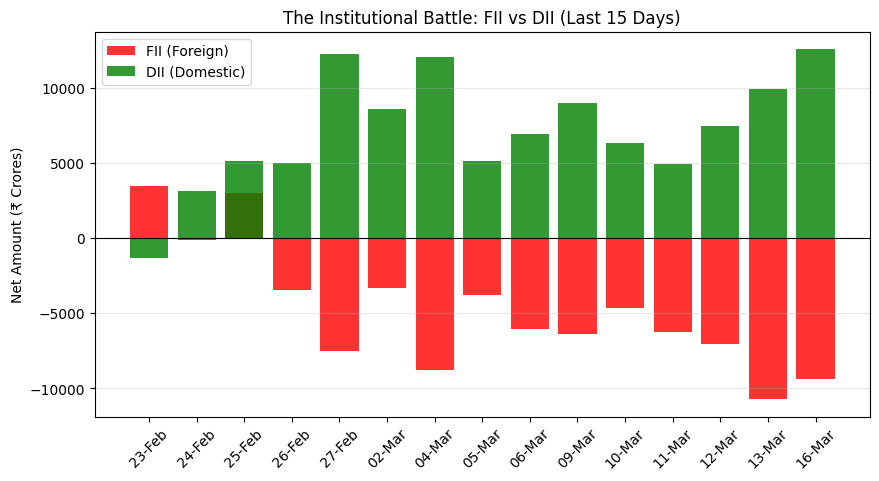

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. THIS IS THE LINE YOU MISSED: Convert text to actual Dates
master_df['Date'] = pd.to_datetime(master_df['Date'])

# 2. Prepare data (latest 15 days)
plot_df = master_df.sort_values(by='Date').tail(15)

# 3. Build the Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(plot_df['Date'].dt.strftime('%d-%b'), plot_df['FII_Net'], color='red', label='FII (Foreign)', alpha=0.8)
plt.bar(plot_df['Date'].dt.strftime('%d-%b'), plot_df['DII_Net'], color='green', label='DII (Domestic)', alpha=0.8)

# 4. Design & Labels
plt.title('The Institutional Battle: FII vs DII (Last 15 Days)')
plt.ylabel('Net Amount (₹ Crores)')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [11]:
import pandas as pd

# 1. Load the Nifty data you just downloaded
nifty_df = pd.read_csv('../data/nifty50.csv')

# 2. Clean the Price column (Scrub the commas and turn into numbers)
nifty_df['Price'] = nifty_df['Price'].astype(str).str.replace(',', '').astype(float)

# 3. Convert both Date columns to official DateTime objects so they match perfectly
nifty_df['Date'] = pd.to_datetime(nifty_df['Date'], dayfirst=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])

# 4. THE MERGE: Stitch them together where the dates match
# We only bring over the 'Price' column so we don't clutter your database
impact_df = pd.merge(master_df, nifty_df[['Date', 'Price']], on='Date', how='inner')

# 5. Sort chronologically and check the engine
impact_df = impact_df.sort_values(by='Date')

print("✅ Merge Successful! Your database now has Market Prices.")
display(impact_df.tail())

✅ Merge Successful! Your database now has Market Prices.


,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net,Price
3,2026-03-10,13188.32,17860.96,-4672.64,17202.49,10869.23,6333.26,24261.60
2,2026-03-11,11448.68,17715.99,-6267.31,16044.16,11078.63,4965.53,23866.85
1,2026-03-12,15373.05,22422.92,-7049.87,19439.56,11989.79,7449.77,23639.15
0,2026-03-13,11923.16,22639.80,-10716.64,22707.84,12730.42,9977.42,23151.10
9,2026-03-16,11566.51,20932.03,-9365.52,25150.41,12557.05,12593.36,23408.80


In [12]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [13]:
%pip install nbformat --upgrade

Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install plotly nbformat ipython --upgrade

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
# Reloading both to be 100% safe
master_df = pd.read_csv('../data/fii_dii_master_database.csv')
nifty_df = pd.read_csv('../data/nifty50.csv')

# Quick cleaning and merge
nifty_df['Price'] = nifty_df['Price'].astype(str).str.replace(',', '').astype(float)
nifty_df['Date'] = pd.to_datetime(nifty_df['Date'], dayfirst=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])

impact_df = pd.merge(master_df, nifty_df[['Date', 'Price']], on='Date', how='inner')
impact_df = impact_df.sort_values(by='Date')

print("✅ Step 1 Success: Data is loaded and merged!")

✅ Step 1 Success: Data is loaded and merged!


In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plot_df = impact_df.tail(15)
dates = plot_df['Date'].dt.strftime('%d-%b')

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(x=dates, y=plot_df['FII_Net'], name="FII", marker_color='#ef5350'), secondary_y=False)
fig.add_trace(go.Bar(x=dates, y=plot_df['DII_Net'], name="DII", marker_color='#66bb6a'), secondary_y=False)
fig.add_trace(go.Scatter(x=dates, y=plot_df['Price'], name="Nifty 50", mode='lines+markers', line=dict(color='#0d47a1', width=3)), secondary_y=True)

fig.update_layout(title_text="<b>Interactive Dashboard</b>", barmode='group', hovermode="x unified", template="plotly_white")
fig.show()

In [17]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# PART 1: REBUILD THE MASTER DATABASE
# ==========================================
def clean_data(file_path):
    raw = pd.read_csv(file_path)
    clean = raw.iloc[2:].copy()
    clean.columns = ['Date', 'FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    
    cols = ['FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    for col in cols:
        clean[col] = clean[col].astype(str).str.replace(',', '').str.strip()
        clean[col] = pd.to_numeric(clean[col], errors='coerce')
    return clean.dropna(subset=['Date'])

# Load the raw files 
jan_df = clean_data('../data/fii_raw_jan_2026.csv')
feb_df = clean_data('../data/fii_history_2026-02.csv') 
march_df = clean_data('../data/fii_raw_march_2026.csv')

# Stack them, sort them, and save the permanent Master File
master_df = pd.concat([jan_df, feb_df, march_df], ignore_index=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])
master_df = master_df.drop_duplicates(subset=['Date']).sort_values(by='Date')
master_df.to_csv('../data/fii_dii_master_database.csv', index=False)
print(f"✅ Master Database Updated! Total Trading Days: {len(master_df)}")

# ==========================================
# PART 2: THE NIFTY MERGE & DASHBOARD
# ==========================================
nifty_df = pd.read_csv('../data/nifty50.csv')
nifty_df['Price'] = nifty_df['Price'].astype(str).str.replace(',', '').astype(float)
nifty_df['Date'] = pd.to_datetime(nifty_df['Date'], dayfirst=True)

# Merge the newly updated master with Nifty
impact_df = pd.merge(master_df, nifty_df[['Date', 'Price']], on='Date', how='inner')
impact_df = impact_df.sort_values(by='Date')

# Plot the latest 15 days
plot_df = impact_df.tail(15)
dates = plot_df['Date'].dt.strftime('%d-%b')

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(x=dates, y=plot_df['FII_Net'], name="FII", marker_color='#ef5350'), secondary_y=False)
fig.add_trace(go.Bar(x=dates, y=plot_df['DII_Net'], name="DII", marker_color='#66bb6a'), secondary_y=False)
fig.add_trace(go.Scatter(x=dates, y=plot_df['Price'], name="Nifty 50", mode='lines+markers', line=dict(color='#0d47a1', width=3)), secondary_y=True)

fig.update_layout(title_text="<b>Live Market Impact (Updated Daily)</b>", barmode='group', hovermode="x unified", template="plotly_white")
fig.show()

✅ Master Database Updated! Total Trading Days: 51


In [18]:
# --- DAY 6: SIGNAL LOGIC ENGINE ---

def calculate_streak(series):
    streak = 0
    # We look at the data from newest to oldest
    for value in series:
        # If the first value is negative, we count selling streak
        if series.iloc[0] < 0:
            if value < 0: streak += 1
            else: break
        # If the first value is positive, we count buying streak
        else:
            if value > 0: streak += 1
            else: break
    return streak

# Get the latest data sorted by date (Newest first)
latest_data = impact_df.sort_values(by='Date', ascending=False)

# Calculate Streaks
fii_streak = calculate_streak(latest_data['FII_Net'])
dii_streak = calculate_streak(latest_data['DII_Net'])

# Determine the "Mood"
fii_mood = "🔴 SELLING" if latest_data['FII_Net'].iloc[0] < 0 else "🟢 BUYING"
dii_mood = "🟢 BUYING" if latest_data['DII_Net'].iloc[0] > 0 else "🔴 SELLING"

# --- THE INTELLIGENCE BRIEFING ---
print(f"🕵️ MARKET INTELLIGENCE REPORT: {latest_data['Date'].iloc[0].strftime('%d-%b-%Y')}")
print(f"--------------------------------------------------")
print(f"FII Status: {fii_mood} Streak: {fii_streak} Days")
print(f"DII Status: {dii_mood} Streak: {dii_streak} Days")

# A simple "Alert" logic
if fii_streak >= 5:
    print(f"\n⚠️ ALERT: FII selling is overextended ({fii_streak} days). Watch for short covering!")

🕵️ MARKET INTELLIGENCE REPORT: 16-Mar-2026
--------------------------------------------------
FII Status: 🔴 SELLING Streak: 12 Days
DII Status: 🟢 BUYING Streak: 14 Days

⚠️ ALERT: FII selling is overextended (12 days). Watch for short covering!


In [19]:
# Calculate Net Institutional Impact
latest_fii = latest_data['FII_Net'].iloc[0]
latest_dii = latest_data['DII_Net'].iloc[0]
net_impact = latest_fii + latest_dii

print(f"--------------------------------------------------")
print(f"Net Institutional Flow: {net_impact:,.2f} Cr")

if net_impact > 0:
    print("Market Sentiment: ✅ BULLISH (DIIs are absorbing the selling)")
else:
    print("Market Sentiment: ❌ BEARISH (FII selling is overpowering the market)")

--------------------------------------------------
Net Institutional Flow: 3,227.84 Cr
Market Sentiment: ✅ BULLISH (DIIs are absorbing the selling)


In [20]:
# ==========================================
# PHASE 3 PREVIEW: THE VOLATILITY GAUGE 
# ==========================================

# 1. Calculate the historical Average and Standard Deviation
fii_mean = impact_df['FII_Net'].mean()
fii_std = impact_df['FII_Net'].std()

# 2. Get today's actual FII number
latest_fii_net = impact_df['FII_Net'].iloc[-1] # Grabs the most recent day

# 3. Calculate the Z-Score (The 'Panic' Metric)
z_score = (latest_fii_net - fii_mean) / fii_std

# 4. Print the Intelligence Briefing
print(f"🌪️ VOLATILITY GAUGE (Z-SCORE ANALYSIS)")
print(f"--------------------------------------------------")
print(f"Historical Average FII Flow: {fii_mean:,.2f} Cr")
print(f"Normal Volatility Range: +/- {fii_std:,.2f} Cr")
print(f"Today's FII Z-Score: {z_score:.2f}")
print(f"--------------------------------------------------")

# 5. The Alert System
if z_score <= -2.0:
    print("🚨 ALERT: EXTREME PANIC SELLING DETECTED (2+ Std Devs).")
    print("Market is statistically oversold. Watch for a sharp short-covering bounce!")
elif z_score >= 2.0:
    print("🚨 ALERT: EXTREME EUPHORIA BUYING DETECTED (2+ Std Devs).")
    print("Market is statistically overbought.")
else:
    print("✅ Normal Volatility: FII activity is within expected statistical ranges.")

🌪️ VOLATILITY GAUGE (Z-SCORE ANALYSIS)
--------------------------------------------------
Historical Average FII Flow: -2,241.66 Cr
Normal Volatility Range: +/- 3,426.37 Cr
Today's FII Z-Score: -2.08
--------------------------------------------------
🚨 ALERT: EXTREME PANIC SELLING DETECTED (2+ Std Devs).
Market is statistically oversold. Watch for a sharp short-covering bounce!
